## Yellow-legged hornet model

11 - Patch construction

12 - Grid Search

13 - PSO

**14 - Simulation**

15 - Map

Spatial Division 1

 Region 1: France

 Region 2: others

Spatial Division 2
**bold text**
 Region 1: France _+ Portugal

 Region 2: others


## Division 2 - FR+PT as Region 1

(Divition 1 -FR + PT as Region 1)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image

In [ ]:
## ONLY PARTITION 2

patch_df = pd.read_csv("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/hornet_patch_attributes_V5.csv")

D_ij = np.load("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/hornet_D_shortest_global_V5.npy")

In [ ]:
patch_df.columns

Index(['patch_id', 'cell_area', 'land_area', 'land_prop', 'A_i', 'occyear1',
       'occyear2', 'region'],
      dtype='object')

In [ ]:
O_j = patch_df["occyear2"].to_numpy(dtype=float)

obsyear1 = patch_df["occyear1"].to_numpy(dtype=float)
obsyear2 = patch_df["occyear2"].to_numpy(dtype=float)

A_j = patch_df["A_i"].to_numpy(dtype=float)

land_area = patch_df["land_area"].to_numpy(dtype=float)
land_prop = patch_df["land_prop"].to_numpy(dtype=float)

patch_id = patch_df["patch_id"].to_numpy()
region = patch_df["region"].to_numpy()

In [ ]:
print("n patches =", len(patch_id))
print("occupied year1 =", int(obsyear1.sum()))
print("occupied year2 =", int(obsyear2.sum()))

n patches = 2567
occupied year1 = 866
occupied year2 = 794


In [ ]:
# # Grid Search - Partition  2
# gs_d2 = (0.2000, 45.0000, 0.7500, 0.1250,
#          0.1500, 135.0000, 0.0078, 0.0025)

# # PSO - Partition 2
# pso_d2 = (1.1259, 88.5857, 4.3052, 6.8570,
#           0.1062, 57.6583, 6.5898, 0.4236)

In [ ]:
# Grid Search - Partition 2
gs_d2_params = {
    "alpha_reg1": 0.2000,
    "y_reg1": 45.0000,
    "e_reg1": 0.7500,
    "x_reg1": 0.1250,
    "alpha_reg2": 0.1500,
    "y_reg2": 135.0000,
    "e_reg2": 0.0078,
    "x_reg2": 0.0025
}


# PSO - Partition 2
pso_d2_params = {
    "alpha_reg1": 1.1259,
    "y_reg1": 88.5857,
    "e_reg1": 4.3052,
    "x_reg1": 6.8570,
    "alpha_reg2": 0.1062,
    "y_reg2": 57.6583,
    "e_reg2": 6.5898,
    "x_reg2": 0.4236
}

In [ ]:
def run_ifm_simulation(alpha_reg1, y_reg1, e_reg1, x_reg1,
                     alpha_reg2, y_reg2, e_reg2, x_reg2,
                     n_steps):

    region = patch_df["region"].to_numpy()

    alpha_i = np.where(region == 1, alpha_reg1, alpha_reg2)
    y_i = np.where(region == 1, y_reg1, y_reg2)
    e_i = np.where(region == 1, e_reg1, e_reg2)
    x_i = np.where(region == 1, x_reg1, x_reg2)

    K_ij = np.exp(-alpha_i[:, None] * D_ij)
    np.fill_diagonal(K_ij, 0)

    E_i = np.minimum(e_i / (A_j ** x_i), 1)

    p_current = patch_df["occyear2"].to_numpy(dtype=float)

    simulation_results = []

    for step in range(1, n_steps + 1):

        S_i = K_ij @ (p_current * A_j)
        C_i = S_i**2 / (S_i**2 + y_i**2)


        p_next = C_i*(1 - p_current)  + (1 - (1 - C_i) * E_i)*p_current


        simulation_results.append((step, E_i.copy(),  S_i.copy(), C_i.copy(), p_next.copy()))

        p_current = p_next.copy()

    return simulation_results



---



In [ ]:
# 2 GS Division 2 deterministic simulation

n_steps = 100

region_array = patch_df["region"].to_numpy()

patch_ids = patch_df["patch_id"].to_numpy()

map_steps = {
    step: 2018 + step * 2
    for step in range(1, n_steps + 1, 5)
}

simulation_results_d2_gs_deter = run_ifm_simulation(
    **gs_d2_params,
    n_steps=n_steps
)

all_results_d2_gs_deter = []

patch_results_d2_gs_deter = []

for step, E_i, S_i, C_i, p_next in simulation_results_d2_gs_deter:

    # region
    for region in [1, 2]:

        mask = region_array == region

        all_results_d2_gs_deter.append({

            "step": step,
            "region": region,
            "mean_E": E_i[mask].mean(),
            "mean_S": S_i[mask].mean(),
            "mean_C": C_i[mask].mean(),
            "mean_occupancy": p_next[mask].mean(),
            "n_pred": (p_next[mask] > 0.5).sum()

        })

    # patch
    if step in map_steps:

        for i in range(len(patch_df)):

            patch_results_d2_gs_deter.append({

                "step": step,
                "year": map_steps[step],
                "patch_id": patch_ids[i],
                "region": region_array[i],
                "E_i": E_i[i],
                "S_i": S_i[i],
                "C_i": C_i[i],
                "p_next": p_next[i]

            })

# region

summary_d2_gs_deter = pd.DataFrame(
    all_results_d2_gs_deter
)

# patch

patch_results_d2_gs_deter = pd.DataFrame(
    patch_results_d2_gs_deter
)

print(summary_d2_gs_deter)

print(patch_results_d2_gs_deter.head())

     step  region    mean_E     mean_S    mean_C  mean_occupancy  n_pred
0       1       1  0.360500  11.688236  0.094833        0.267724     514
1       1       2  0.007686  29.270696  0.092772        0.290921     282
2       2       1  0.360500   9.599130  0.067081        0.215719     317
3       2       2  0.007686  29.682018  0.093524        0.298470     284
4       3       1  0.360500   7.794638  0.046553        0.171417      37
..    ...     ...       ...        ...       ...             ...     ...
195    98       2  0.007686  90.885925  0.317911        0.900863     913
196    99       1  0.360500   0.958285  0.005845        0.013340       1
197    99       2  0.007686  91.044875  0.318498        0.902513     915
198   100       1  0.360500   0.960676  0.005862        0.013379       1
199   100       2  0.007686  91.199939  0.319071        0.904128     916

[200 rows x 7 columns]
   step  year  patch_id  region       E_i           S_i           C_i  \
0     1  2020         0    

In [ ]:
summary_d2_gs_deter

,step,region,mean_E,mean_S,mean_C,mean_occupancy,n_pred
0,1,1,0.360500,11.688236,0.094833,0.267724,514
1,1,2,0.007686,29.270696,0.092772,0.290921,282
2,2,1,0.360500,9.599130,0.067081,0.215719,317
3,2,2,0.007686,29.682018,0.093524,0.298470,284
4,3,1,0.360500,7.794638,0.046553,0.171417,37
...,...,...,...,...,...,...,...
195,98,2,0.007686,90.885925,0.317911,0.900863,913
196,99,1,0.360500,0.958285,0.005845,0.013340,1
197,99,2,0.007686,91.044875,0.318498,0.902513,915
198,100,1,0.360500,0.960676,0.005862,0.013379,1


In [ ]:
summary_d2_gs_deter.to_csv(
    "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"
    "hornet_summary_d2_gs_deter.csv",
    index=False
)

patch_results_d2_gs_deter.to_csv(
    "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"
    "hornet_patch_results_d2_gs_deter.csv",
    index=False
)

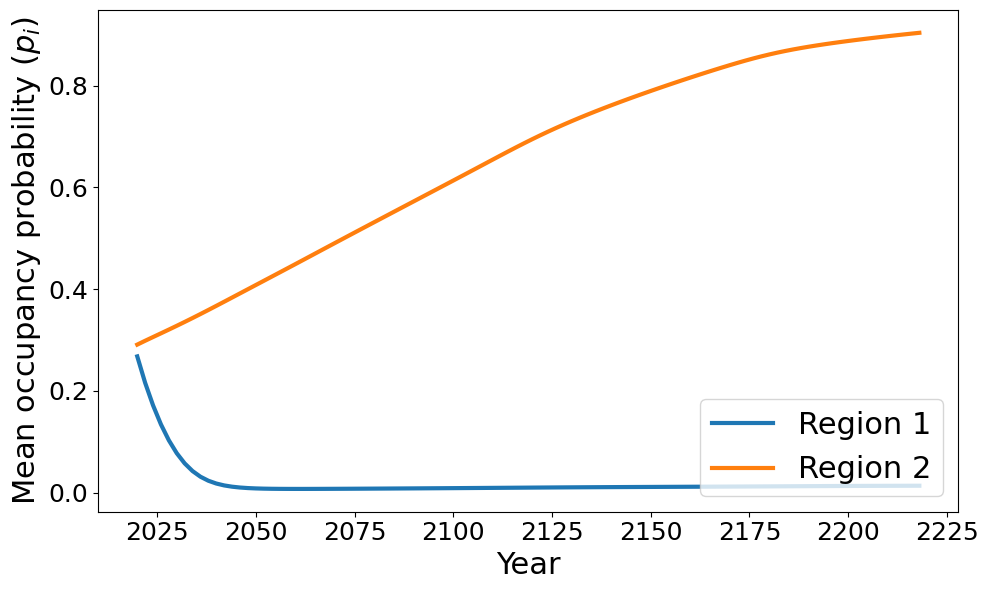

In [ ]:
plt.figure(figsize=(10, 6))

for region in [1, 2]:
    df = summary_d2_gs_deter[
        summary_d2_gs_deter["region"] == region
    ]

    plt.plot(
        2018 + df["step"] * 2,
        df["mean_occupancy"],
        linewidth=3,
        label=f"Region {region}"
    )

plt.xlabel("Year", fontsize=22)
plt.ylabel(r"Mean occupancy probability ($p_i$)", fontsize=22)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.legend(fontsize=22, loc="lower right")

plt.tight_layout()
plt.show()

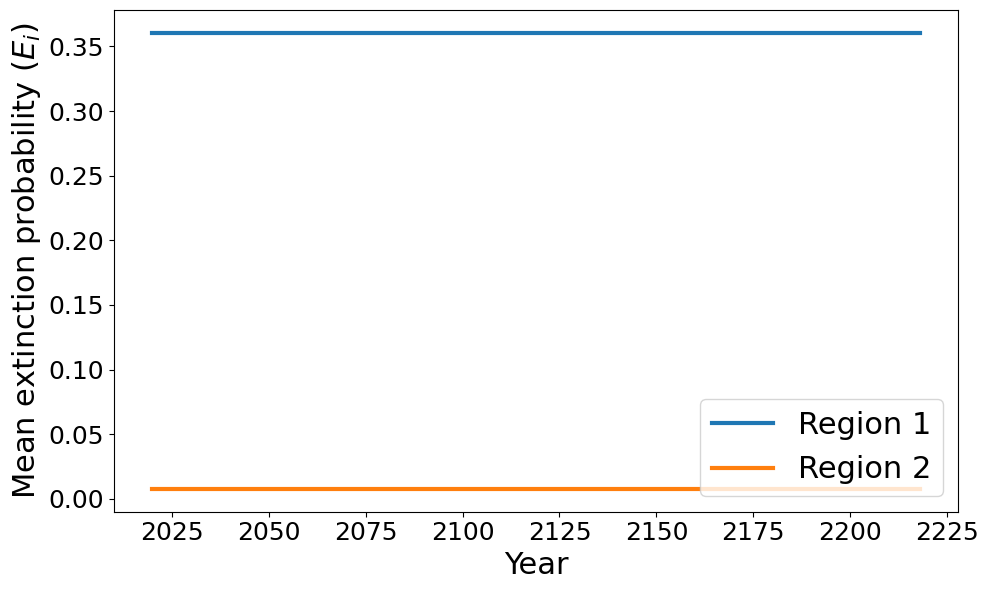

In [ ]:
plt.figure(figsize=(10, 6))

for region in [1, 2]:
    df = summary_d2_gs_deter[
        summary_d2_gs_deter["region"] == region
    ]

    plt.plot(
        2018 + df["step"] * 2,
        df["mean_E"],
        linewidth=3,
        label=f"Region {region}"
    )

plt.xlabel("Year", fontsize=22)
plt.ylabel(r"Mean extinction probability ($E_i$)", fontsize=22)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.legend(fontsize=22, loc="lower right")

plt.tight_layout()
plt.show()

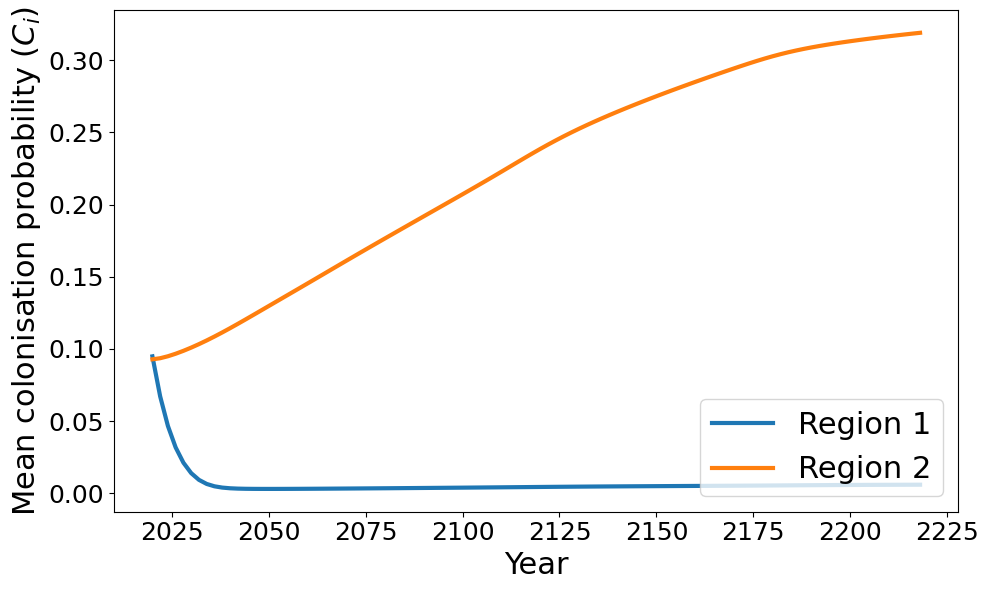

In [ ]:
plt.figure(figsize=(10, 6))

for region in [1, 2]:
    df = summary_d2_gs_deter[
        summary_d2_gs_deter["region"] == region
    ]

    plt.plot(
        2018 + df["step"] * 2,
        df["mean_C"],
        linewidth=3,
        label=f"Region {region}"
    )

plt.xlabel("Year", fontsize=22)
plt.ylabel(r"Mean colonisation probability ($C_i$)", fontsize=22)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.legend(fontsize=22, loc="lower right")

plt.tight_layout()
plt.show()

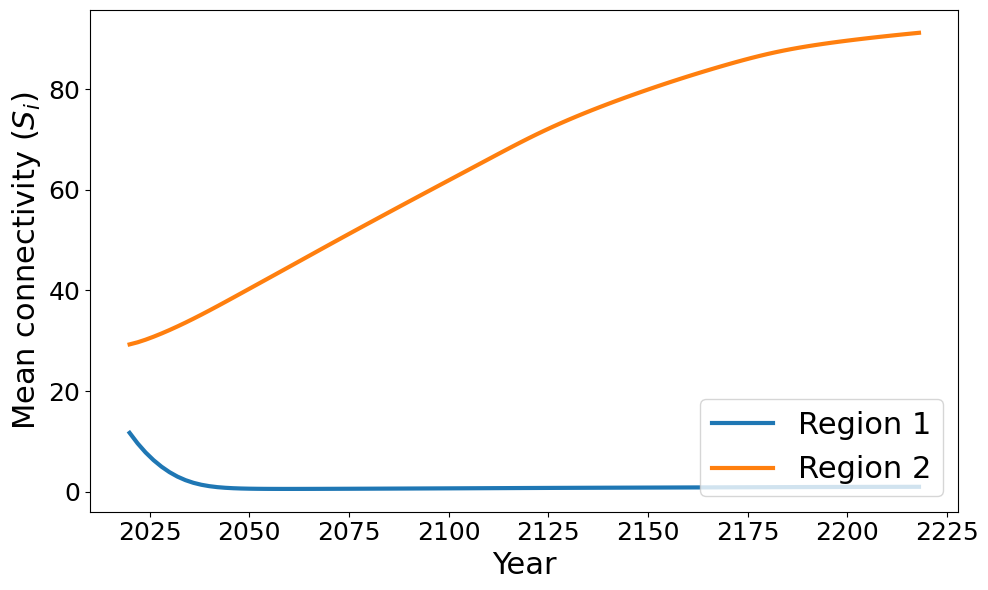

In [ ]:
plt.figure(figsize=(10, 6))

for region in [1, 2]:
    df = summary_d2_gs_deter[
        summary_d2_gs_deter["region"] == region
    ]

    plt.plot(
        2018 + df["step"] * 2,
        df["mean_S"],
        linewidth=3,
        label=f"Region {region}"
    )

plt.xlabel("Year", fontsize=22)
plt.ylabel(r"Mean connectivity ($S_i$)", fontsize=22)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.legend(fontsize=22, loc="lower right")

plt.tight_layout()
plt.show()



---



In [ ]:
####################################################################
# 2 PSO Division 2 -- stochastic replicates

%%time

# 2 PSO Division 2 deterministic simulation

n_steps = 100

region_array = patch_df["region"].to_numpy()

patch_ids = patch_df["patch_id"].to_numpy()

map_steps = {
    step: 2018 + step * 2
    for step in range(1, n_steps + 1, 5)
}

simulation_results_d2_pso_deter = run_ifm_simulation(
    **pso_d2_params,
    n_steps=n_steps
)

all_results_d2_pso_deter = []

patch_results_d2_pso_deter = []

for step, E_i, S_i, C_i, p_next in simulation_results_d2_pso_deter:

    # region
    for region in [1, 2]:

        mask = region_array == region

        all_results_d2_pso_deter.append({

            "step": step,

            "region": region,

            "mean_E": E_i[mask].mean(),

            "mean_S": S_i[mask].mean(),

            "mean_C": C_i[mask].mean(),

            "mean_occupancy": p_next[mask].mean(),

            "n_pred": (p_next[mask] > 0.5).sum()

        })

    # patch
    if step in map_steps:

        for i in range(len(patch_df)):

            patch_results_d2_pso_deter.append({

                "step": step,

                "year": map_steps[step],

                "patch_id": patch_ids[i],

                "region": region_array[i],

                "E_i": E_i[i],

                "S_i": S_i[i],

                "C_i": C_i[i],

                "p_next": p_next[i]

            })

# region
summary_d2_pso_deter = pd.DataFrame(
    all_results_d2_pso_deter
)

# patch
patch_results_d2_pso_deter = pd.DataFrame(
    patch_results_d2_pso_deter
)

print(summary_d2_pso_deter)

print(patch_results_d2_pso_deter.head())

     step  region    mean_E      mean_S        mean_C  mean_occupancy  n_pred
0       1       1  0.002548    0.000004  2.513144e-13        0.326115     512
1       1       2  0.539711   83.069369  3.499011e-01        0.361351     369
2       2       1  0.002548    0.000004  2.513143e-13        0.326115     512
3       2       2  0.539711  106.538363  4.446235e-01        0.456454     480
4       3       1  0.002548    0.000004  2.513143e-13        0.326115     512
..    ...     ...       ...         ...           ...             ...     ...
195    98       2  0.539711  283.731999  9.544311e-01        0.973949     997
196    99       1  0.002548    0.000004  2.513143e-13        0.326115     512
197    99       2  0.539711  283.731999  9.544311e-01        0.973949     997
198   100       1  0.002548    0.000004  2.513143e-13        0.326115     512
199   100       2  0.539711  283.731999  9.544311e-01        0.973949     997

[200 rows x 7 columns]
   step  year  patch_id  region         

In [ ]:
summary_d2_pso_deter.to_csv(
    "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"
    "hornet_summary_d2_pso_deter.csv",
    index=False
)

patch_results_d2_pso_deter.to_csv(
    "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"
    "hornet_patch_results_d2_pso_deter.csv",
    index=False
)

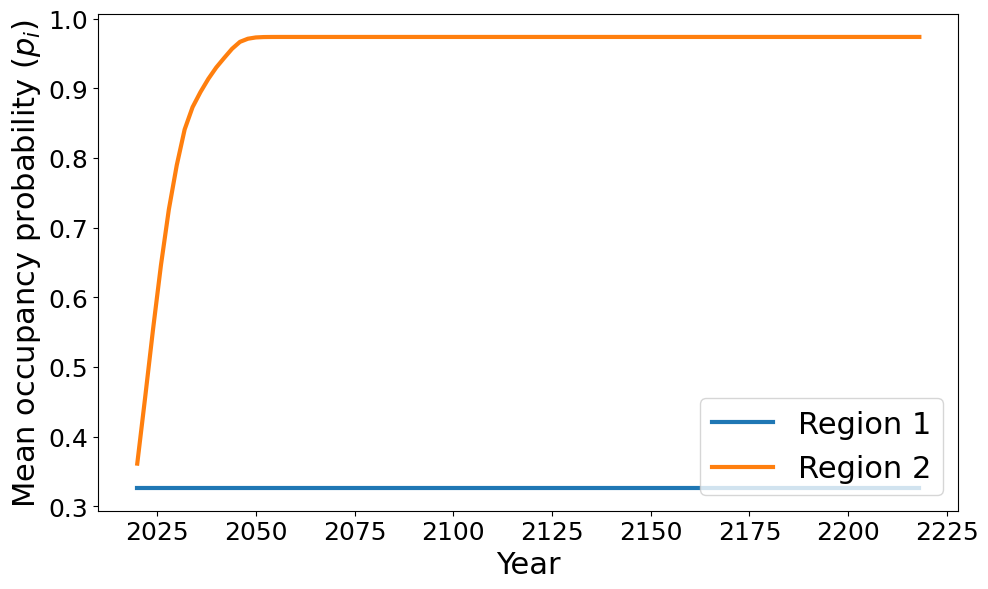

In [ ]:
# Mean occupancy probability p_i

plt.figure(figsize=(10, 6))

for region in [1, 2]:
    df = summary_d2_pso_deter[
        summary_d2_pso_deter["region"] == region
    ]

    plt.plot(
        2018 + df["step"] * 2,
        df["mean_occupancy"],
        linewidth=3,
        label=f"Region {region}"
    )

plt.xlabel("Year", fontsize=22)
plt.ylabel(r"Mean occupancy probability ($p_i$)", fontsize=22)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.legend(
    fontsize=22,
    loc="lower right"
)

plt.tight_layout()
plt.show()

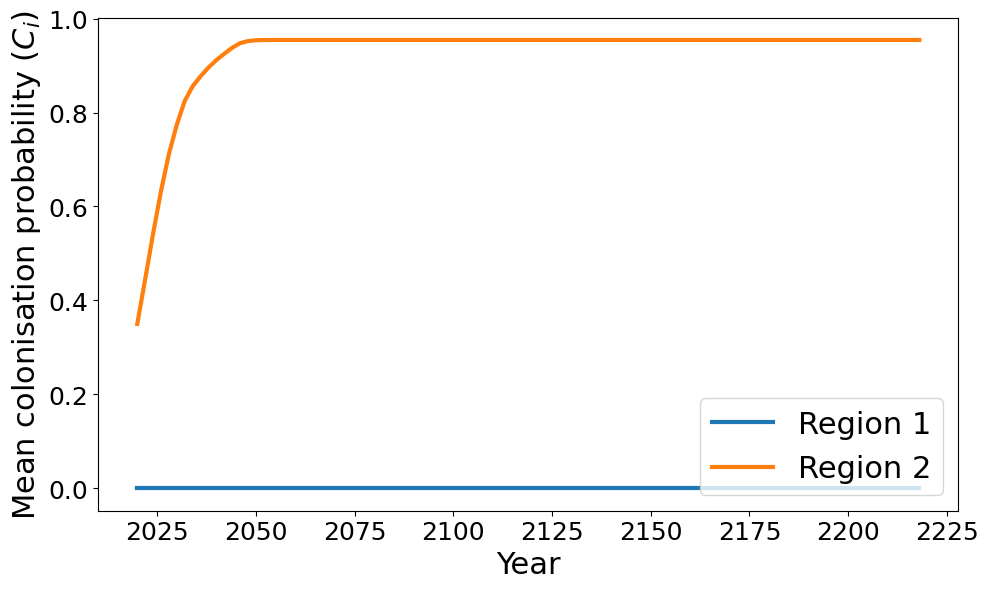

In [ ]:
# Mean colonisation probability C_i

plt.figure(figsize=(10, 6))

for region in [1, 2]:
    df = summary_d2_pso_deter[
        summary_d2_pso_deter["region"] == region
    ]

    plt.plot(
        2018 + df["step"] * 2,
        df["mean_C"],
        linewidth=3,
        label=f"Region {region}"
    )

plt.xlabel("Year", fontsize=22)
plt.ylabel(r"Mean colonisation probability ($C_i$)", fontsize=22)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.legend(
    fontsize=22,
    loc="lower right"
)

plt.tight_layout()
plt.show()



---



# comparation of region division modelling

In [ ]:
summary_d1_gs_deter = pd.read_csv(
    "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"
    "hornet_summary_d1_gs_deter.csv"
)

print(summary_d1_gs_deter.shape)
print(summary_d1_gs_deter.head())

(200, 7)
   step  region    mean_E        mean_S        mean_C  mean_occupancy  n_pred
0     1       1  0.002145  2.654471e-09  2.150845e-15        0.336707     499
1     1       2  0.055444  2.803902e+01  1.817683e-01        0.291119     308
2     2       1  0.002145  2.654472e-09  2.150845e-15        0.336707     499
3     2       2  0.055444  2.999998e+01  1.944922e-01        0.311039     331
4     3       1  0.002145  2.654472e-09  2.150845e-15        0.336707     499


In [ ]:
print(summary_d2_gs_deter.shape)
print(summary_d2_gs_deter.head())

(200, 7)
   step  region    mean_E     mean_S    mean_C  mean_occupancy  n_pred
0     1       1  0.360500  11.688236  0.094833        0.267724     514
1     1       2  0.007686  29.270696  0.092772        0.290921     282
2     2       1  0.360500   9.599130  0.067081        0.215719     317
3     2       2  0.007686  29.682018  0.093524        0.298470     284
4     3       1  0.360500   7.794638  0.046553        0.171417      37


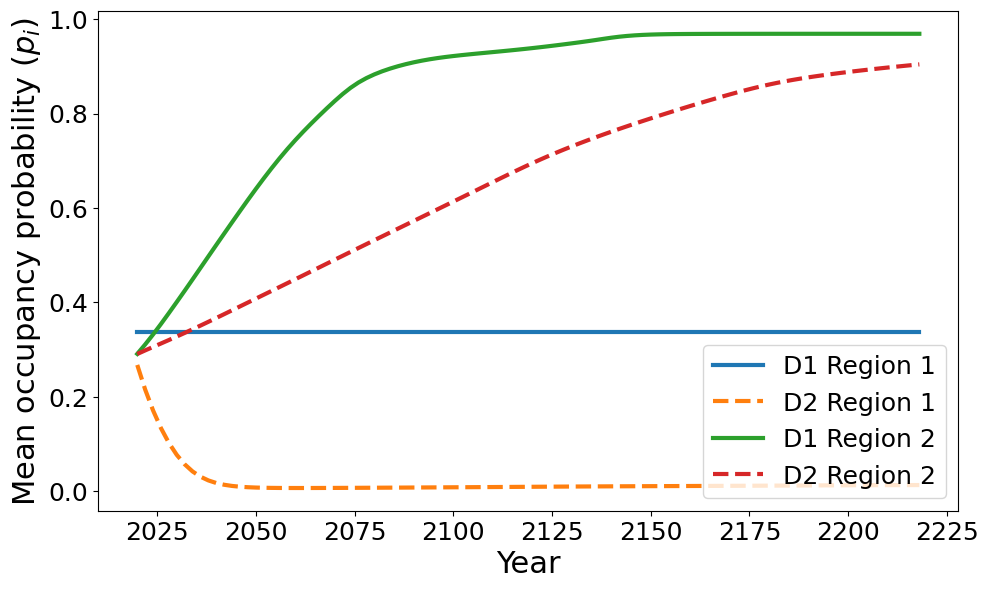

In [ ]:
plt.figure(figsize=(10, 6))

for region in [1, 2]:

    df_d1 = summary_d1_gs_deter[
        summary_d1_gs_deter["region"] == region
    ]

    df_d2 = summary_d2_gs_deter[
        summary_d2_gs_deter["region"] == region
    ]

    plt.plot(
        2018 + df_d1["step"] * 2,
        df_d1["mean_occupancy"],
        linewidth=3,
        linestyle="-",
        label=f"D1 Region {region}"
    )

    plt.plot(
        2018 + df_d2["step"] * 2,
        df_d2["mean_occupancy"],
        linewidth=3,
        linestyle="--",
        label=f"D2 Region {region}"
    )

plt.xlabel("Year", fontsize=22)
plt.ylabel(r"Mean occupancy probability ($p_i$)", fontsize=22)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.legend(
    fontsize=18,
    loc="lower right"
)

plt.tight_layout()
plt.show()

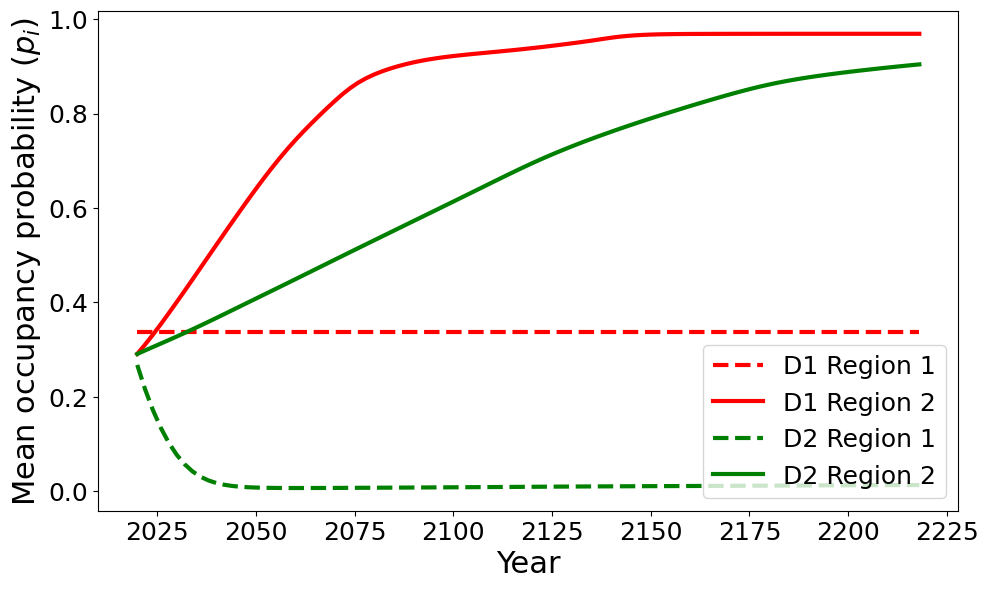

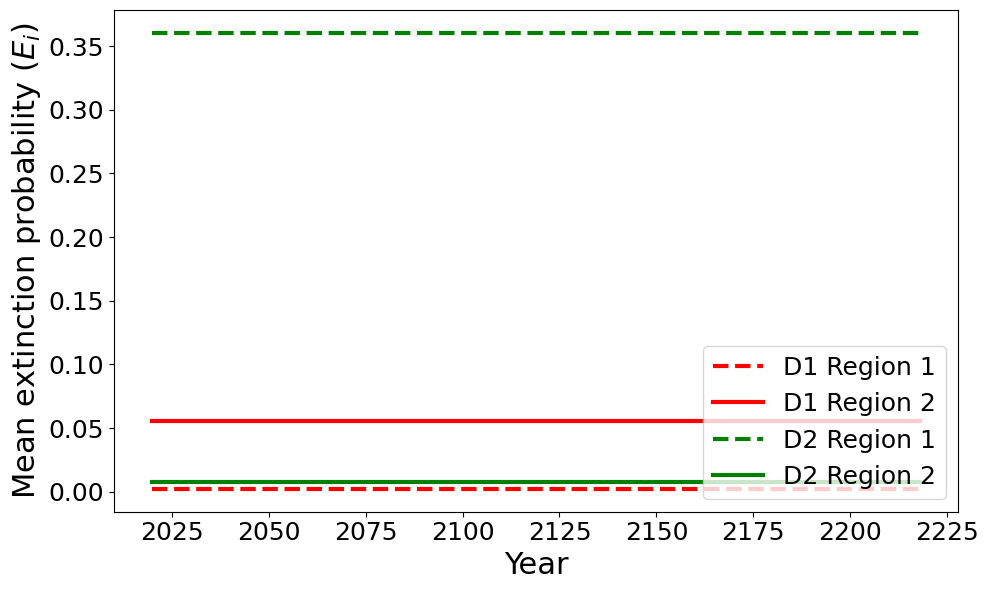

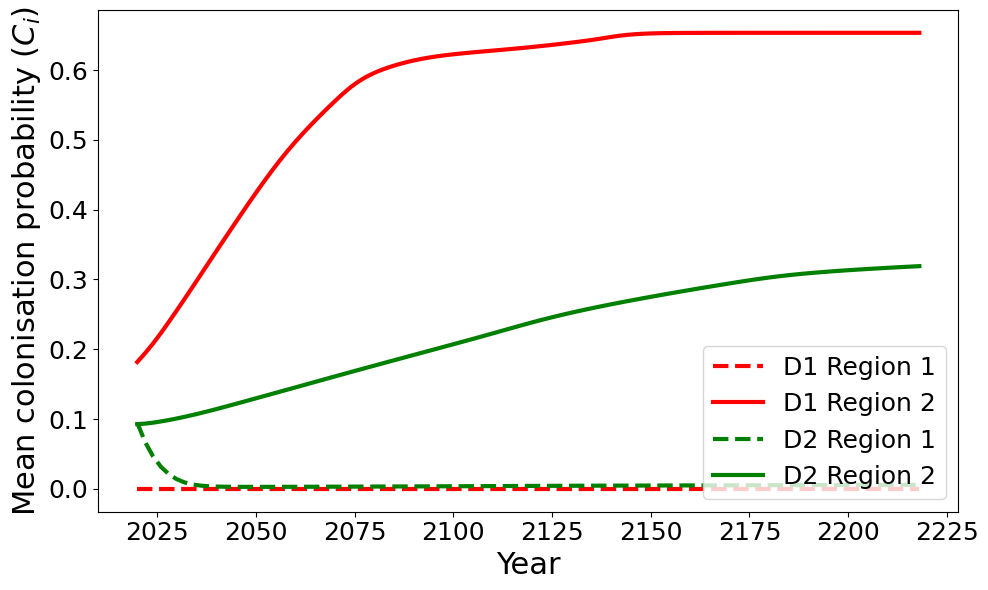

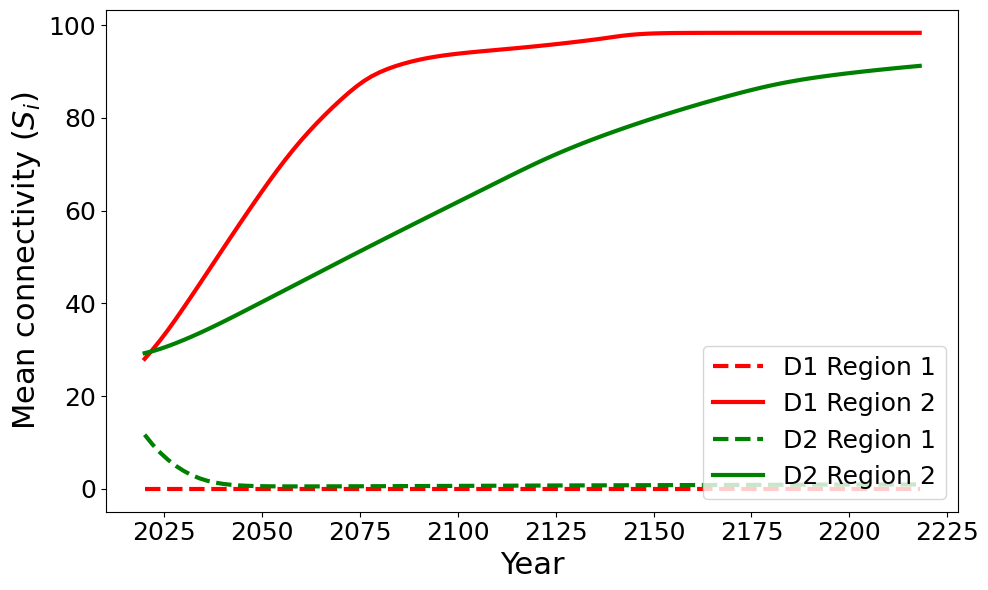

In [ ]:
import matplotlib.pyplot as plt

plot_vars = {
    "mean_occupancy": r"Mean occupancy probability ($p_i$)",
    "mean_E": r"Mean extinction probability ($E_i$)",
    "mean_C": r"Mean colonisation probability ($C_i$)",
    "mean_S": r"Mean connectivity ($S_i$)"
}

for var, ylabel in plot_vars.items():

    plt.figure(figsize=(10, 6))

    # D1 - red
    for region, linestyle in [(1, "--"), (2, "-")]:

        df = summary_d1_gs_deter[
            summary_d1_gs_deter["region"] == region
        ]

        plt.plot(
            2018 + df["step"] * 2,
            df[var],
            linewidth=3,
            linestyle=linestyle,
            color="red",
            label=f"D1 Region {region}"
        )

    # D2 - green
    for region, linestyle in [(1, "--"), (2, "-")]:

        df = summary_d2_gs_deter[
            summary_d2_gs_deter["region"] == region
        ]

        plt.plot(
            2018 + df["step"] * 2,
            df[var],
            linewidth=3,
            linestyle=linestyle,
            color="green",
            label=f"D2 Region {region}"
        )

    plt.xlabel("Year", fontsize=22)
    plt.ylabel(ylabel, fontsize=22)

    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)

    plt.legend(
        fontsize=18,
        loc="lower right"
    )

    plt.tight_layout()
    plt.show()

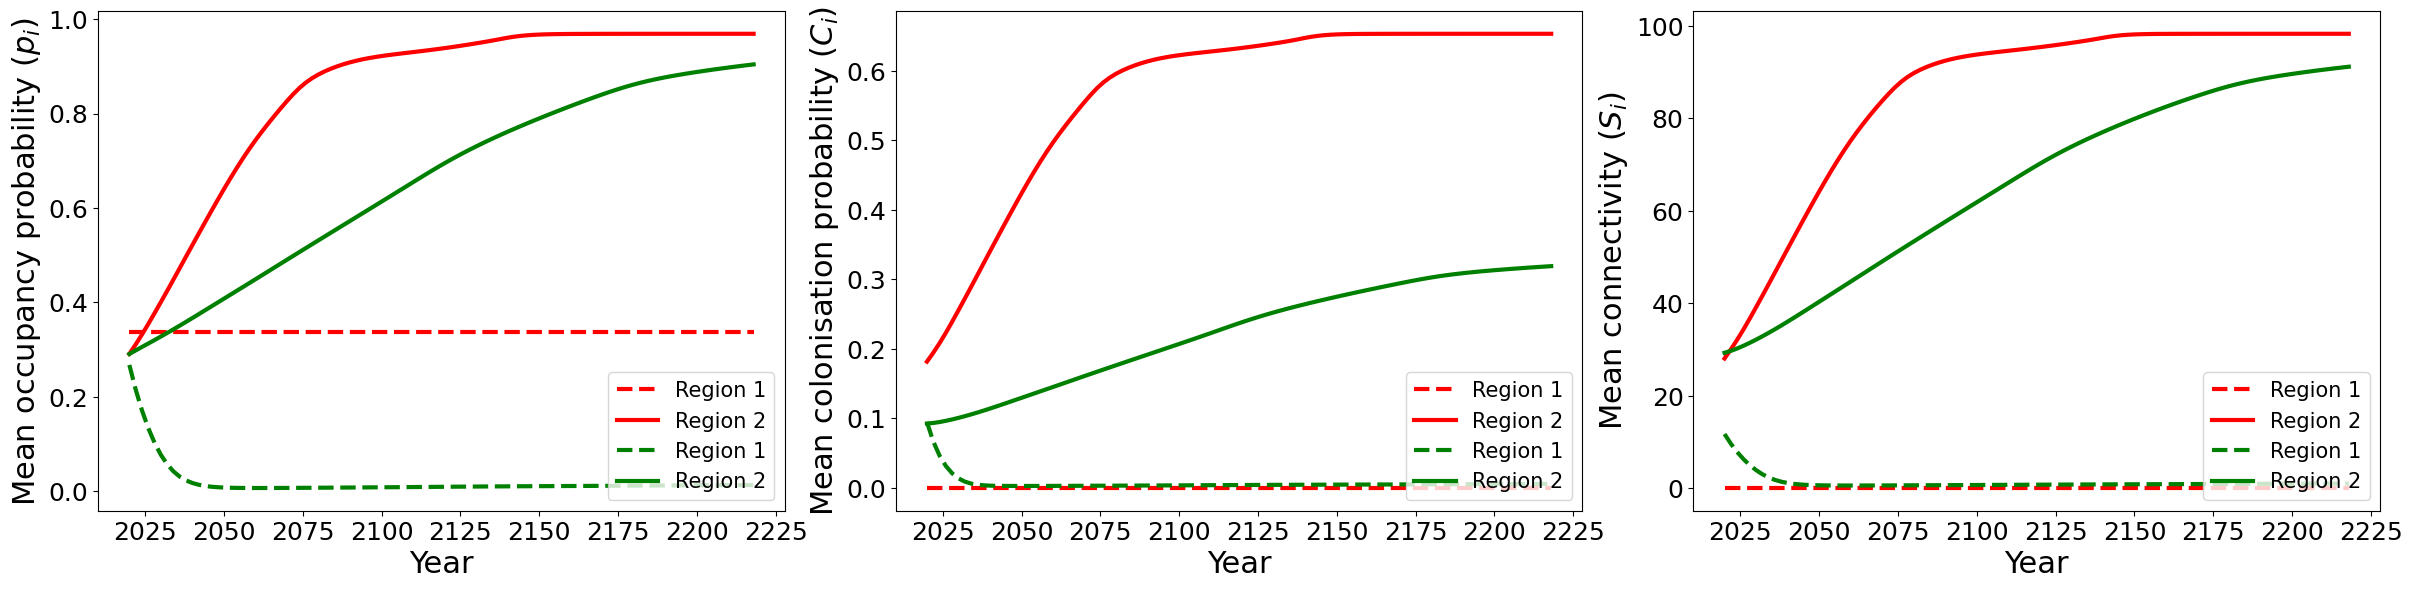

In [ ]:
import matplotlib.pyplot as plt

plot_vars = {
    "mean_occupancy": r"Mean occupancy probability ($p_i$)",
    "mean_C": r"Mean colonisation probability ($C_i$)",
    "mean_S": r"Mean connectivity ($S_i$)"
}

fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 6)
)

for ax, (var, ylabel) in zip(axes, plot_vars.items()):

    # D1 - red
    for region, linestyle in [(1, "--"), (2, "-")]:

        df = summary_d1_gs_deter[
            summary_d1_gs_deter["region"] == region
        ]

        ax.plot(
            2018 + df["step"] * 2,
            df[var],
            linewidth=3,
            linestyle=linestyle,
            color="red",
            label=f"Region {region}"
        )

    # D2 - green
    for region, linestyle in [(1, "--"), (2, "-")]:

        df = summary_d2_gs_deter[
            summary_d2_gs_deter["region"] == region
        ]

        ax.plot(
            2018 + df["step"] * 2,
            df[var],
            linewidth=3,
            linestyle=linestyle,
            color="green",
            label=f"Region {region}"
        )

    ax.set_xlabel("Year", fontsize=22)
    ax.set_ylabel(ylabel, fontsize=22)

    ax.tick_params(
        axis="both",
        labelsize=18
    )

    ax.legend(
        fontsize=15,
        loc="lower right"
    )

plt.tight_layout()
plt.show()

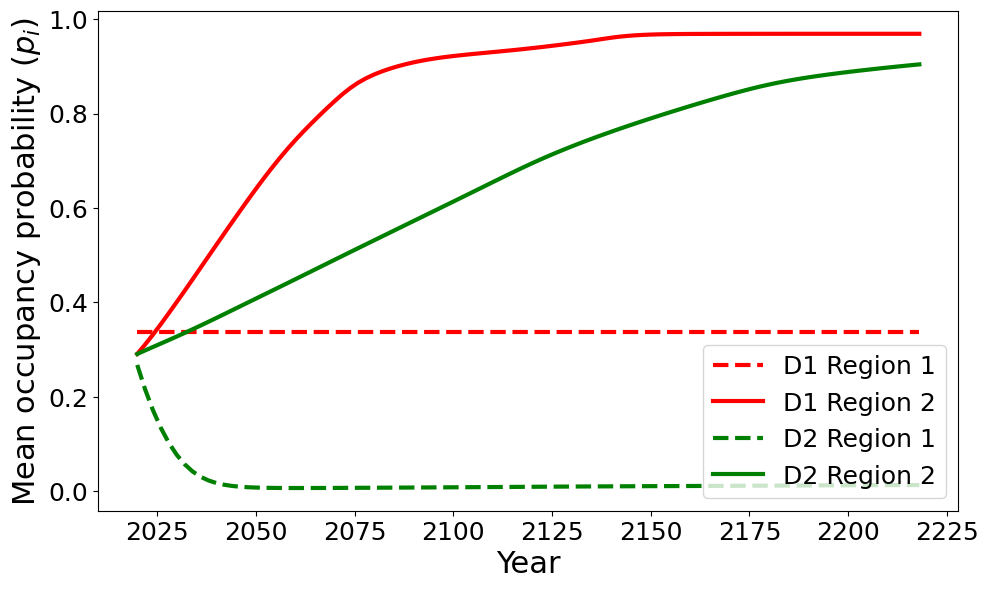

In [ ]:
plt.figure(figsize=(10, 6))

# D1 - red
for region, linestyle in [(1, "--"), (2, "-")]:
    df = summary_d1_gs_deter[
        summary_d1_gs_deter["region"] == region
    ]

    plt.plot(
        2018 + df["step"] * 2,
        df["mean_occupancy"],
        linewidth=3,
        linestyle=linestyle,
        color="red",
        label=f"Region {region}"
    )

# D2 - green
for region, linestyle in [(1, "--"), (2, "-")]:
    df = summary_d2_gs_deter[
        summary_d2_gs_deter["region"] == region
    ]

    plt.plot(
        2018 + df["step"] * 2,
        df["mean_occupancy"],
        linewidth=3,
        linestyle=linestyle,
        color="green",
        label=f"Region {region}"
    )

plt.xlabel("Year", fontsize=22)
plt.ylabel(r"Mean occupancy probability ($p_i$)", fontsize=22)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.legend(fontsize=18, loc="lower right")

plt.tight_layout()
plt.show()

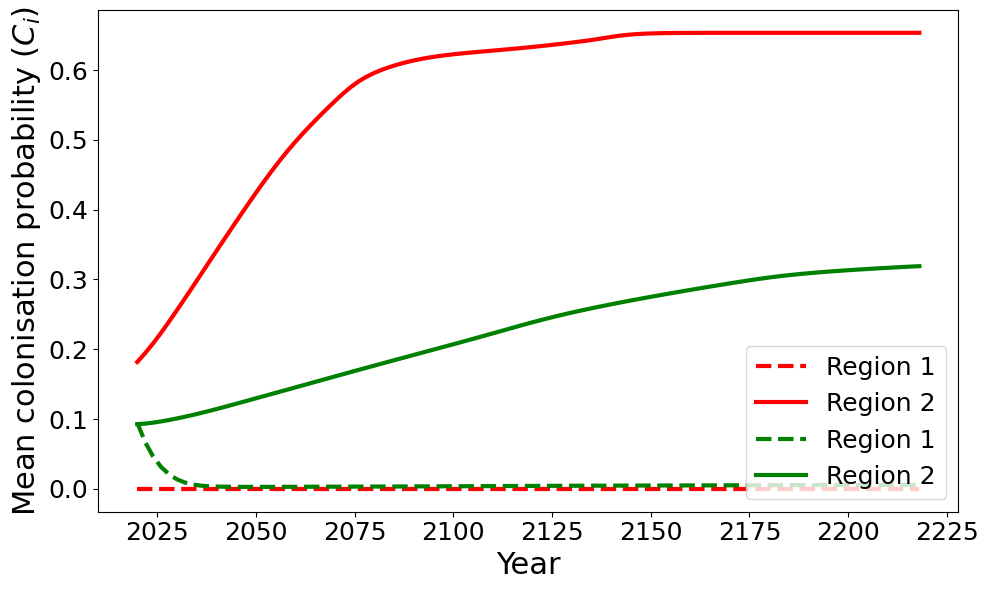

In [ ]:
plt.figure(figsize=(10, 6))

# D1 - red
for region, linestyle in [(1, "--"), (2, "-")]:
    df = summary_d1_gs_deter[
        summary_d1_gs_deter["region"] == region
    ]

    plt.plot(
        2018 + df["step"] * 2,
        df["mean_C"],
        linewidth=3,
        linestyle=linestyle,
        color="red",
        label=f"Region {region}"
    )

# D2 - green
for region, linestyle in [(1, "--"), (2, "-")]:
    df = summary_d2_gs_deter[
        summary_d2_gs_deter["region"] == region
    ]

    plt.plot(
        2018 + df["step"] * 2,
        df["mean_C"],
        linewidth=3,
        linestyle=linestyle,
        color="green",
        label=f"Region {region}"
    )

plt.xlabel("Year", fontsize=22)
plt.ylabel(r"Mean colonisation probability ($C_i$)", fontsize=22)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.legend(fontsize=18, loc="lower right")

plt.tight_layout()
plt.show()

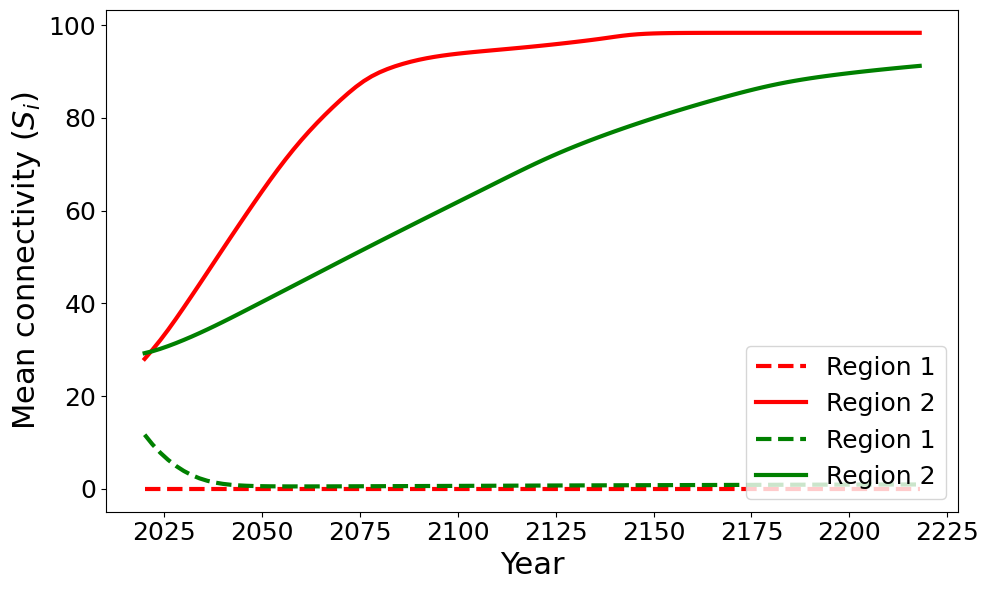

In [ ]:
plt.figure(figsize=(10, 6))

# D1 - red
for region, linestyle in [(1, "--"), (2, "-")]:
    df = summary_d1_gs_deter[
        summary_d1_gs_deter["region"] == region
    ]

    plt.plot(
        2018 + df["step"] * 2,
        df["mean_S"],
        linewidth=3,
        linestyle=linestyle,
        color="red",
        label=f"Region {region}"
    )

# D2 - green
for region, linestyle in [(1, "--"), (2, "-")]:
    df = summary_d2_gs_deter[
        summary_d2_gs_deter["region"] == region
    ]

    plt.plot(
        2018 + df["step"] * 2,
        df["mean_S"],
        linewidth=3,
        linestyle=linestyle,
        color="green",
        label=f"Region {region}"
    )

plt.xlabel("Year", fontsize=22)
plt.ylabel(r"Mean connectivity ($S_i$)", fontsize=22)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.legend(fontsize=18, loc="lower right")

plt.tight_layout()
plt.show()

# Management example

In [ ]:
print(gs_d2_params)

{'alpha_reg1': 0.2, 'y_reg1': 45.0, 'e_reg1': 0.75, 'x_reg1': 0.125, 'alpha_reg2': 0.15, 'y_reg2': 135.0, 'e_reg2': 0.0078, 'x_reg2': 0.0025}


In [ ]:
gs_d2_r1_only_params = gs_d2_params.copy()

gs_d2_r1_only_params["alpha_reg2"] = gs_d2_r1_only_params["alpha_reg1"]
gs_d2_r1_only_params["y_reg2"] = gs_d2_r1_only_params["y_reg1"]
gs_d2_r1_only_params["e_reg2"] = gs_d2_r1_only_params["e_reg1"]
gs_d2_r1_only_params["x_reg2"] = gs_d2_r1_only_params["x_reg1"]

print(gs_d2_r1_only_params)



{'alpha_reg1': 0.2, 'y_reg1': 45.0, 'e_reg1': 0.75, 'x_reg1': 0.125, 'alpha_reg2': 0.2, 'y_reg2': 45.0, 'e_reg2': 0.75, 'x_reg2': 0.125}


In [ ]:
n_steps = 100

region_array = patch_df["region"].to_numpy()
patch_ids = patch_df["patch_id"].to_numpy()

map_steps = {
    step: 2018 + step * 2
    for step in range(1, n_steps + 1, 5)
}


# Run simulation
simulation_results_d2_gs_r1_only_deter = run_ifm_simulation(
    **gs_d2_r1_only_params,
    n_steps=n_steps
)



all_results_d2_gs_r1_only_deter = []
patch_results_d2_gs_r1_only_deter = []

for step, E_i, S_i, C_i, p_next in simulation_results_d2_gs_r1_only_deter:

    for region in [1, 2]:

        mask = region_array == region

        all_results_d2_gs_r1_only_deter.append({
            "step": step,
            "region": region,
            "mean_E": E_i[mask].mean(),
            "mean_S": S_i[mask].mean(),
            "mean_C": C_i[mask].mean(),
            "mean_occupancy": p_next[mask].mean(),
            "n_pred": (p_next[mask] > 0.5).sum()
        })


    if step in map_steps:

        for i in range(len(patch_df)):

            patch_results_d2_gs_r1_only_deter.append({
                "step": step,
                "year": map_steps[step],
                "patch_id": patch_ids[i],
                "region": region_array[i],
                "E_i": E_i[i],
                "S_i": S_i[i],
                "C_i": C_i[i],
                "p_next": p_next[i]
            })




summary_d2_gs_r1_only_deter = pd.DataFrame(
    all_results_d2_gs_r1_only_deter
)

patch_results_d2_gs_r1_only_deter = pd.DataFrame(
    patch_results_d2_gs_r1_only_deter
)


print(summary_d2_gs_r1_only_deter)

print(
    patch_results_d2_gs_r1_only_deter.head()
)




     step  region    mean_E        mean_S        mean_C  mean_occupancy  \
0       1       1  0.360500  1.168824e+01  9.483304e-02    2.677243e-01   
1       1       2  0.359211  9.966390e+00  9.636622e-02    2.209529e-01   
2       2       1  0.360500  9.525242e+00  6.612156e-02    2.151511e-01   
3       2       2  0.359211  7.796665e+00  6.696150e-02    1.771870e-01   
4       3       1  0.360500  7.654228e+00  4.485259e-02    1.699607e-01   
..    ...     ...       ...           ...           ...             ...   
195    98       2  0.359211  2.031088e-17  7.392581e-37    3.436273e-19   
196    99       1  0.360500  1.173072e-17  1.416011e-37    2.026997e-19   
197    99       2  0.359211  1.310612e-17  3.078653e-37    2.217294e-19   
198   100       1  0.360500  7.570078e-18  5.897637e-38    1.308081e-19   
199   100       2  0.359211  8.457099e-18  1.282118e-37    1.430741e-19   

     n_pred  
0       514  
1       282  
2       313  
3       246  
4        30  
..      ...  
1

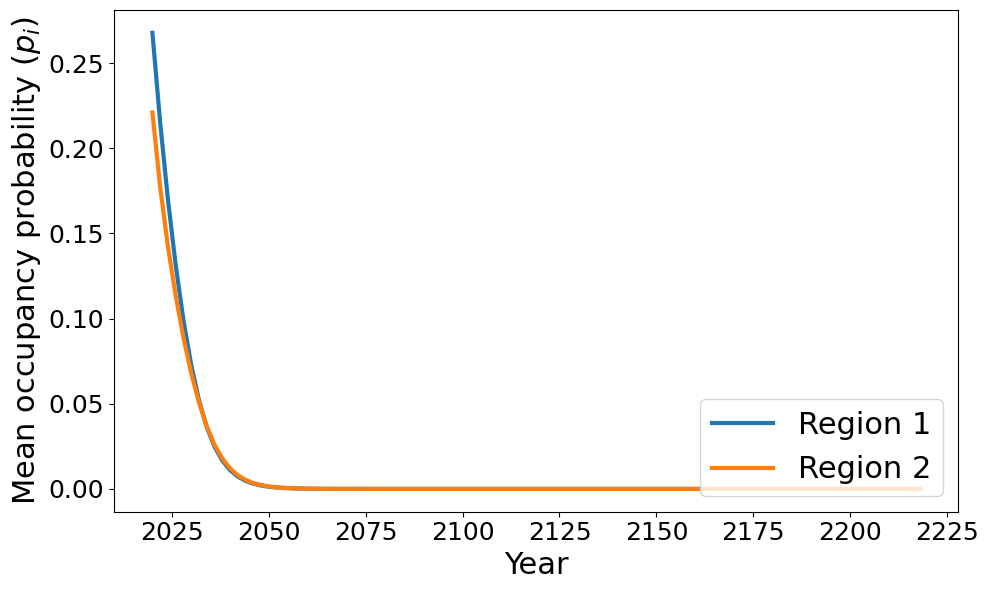

In [ ]:

summary_d2_gs_r1_only_deter.to_csv(
    "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"
    "hornet_summary_d2_gs_r1_only_deter.csv",
    index=False
)

patch_results_d2_gs_r1_only_deter.to_csv(
    "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"
    "hornet_patch_results_d2_gs_r1_only_deter.csv",
    index=False
)



plt.figure(figsize=(10, 6))

for region in [1, 2]:

    df = summary_d2_gs_r1_only_deter[
        summary_d2_gs_r1_only_deter["region"] == region
    ]

    plt.plot(
        2018 + df["step"] * 2,
        df["mean_occupancy"],
        linewidth=3,
        label=f"Region {region}"
    )

plt.xlabel("Year", fontsize=22)
plt.ylabel(r"Mean occupancy probability ($p_i$)", fontsize=22)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.legend(
    fontsize=22,
    loc="lower right"
)

plt.tight_layout()
plt.show()

In [ ]:
summary_d2_gs_r1_only_deter

,step,region,mean_E,mean_S,mean_C,mean_occupancy,n_pred
0,1,1,0.360500,1.168824e+01,9.483304e-02,2.677243e-01,514
1,1,2,0.359211,9.966390e+00,9.636622e-02,2.209529e-01,282
2,2,1,0.360500,9.525242e+00,6.612156e-02,2.151511e-01,313
3,2,2,0.359211,7.796665e+00,6.696150e-02,1.771870e-01,246
4,3,1,0.360500,7.654228e+00,4.485259e-02,1.699607e-01,30
...,...,...,...,...,...,...,...
195,98,2,0.359211,2.031088e-17,7.392581e-37,3.436273e-19,0
196,99,1,0.360500,1.173072e-17,1.416011e-37,2.026997e-19,0
197,99,2,0.359211,1.310612e-17,3.078653e-37,2.217294e-19,0
198,100,1,0.360500,7.570078e-18,5.897637e-38,1.308081e-19,0


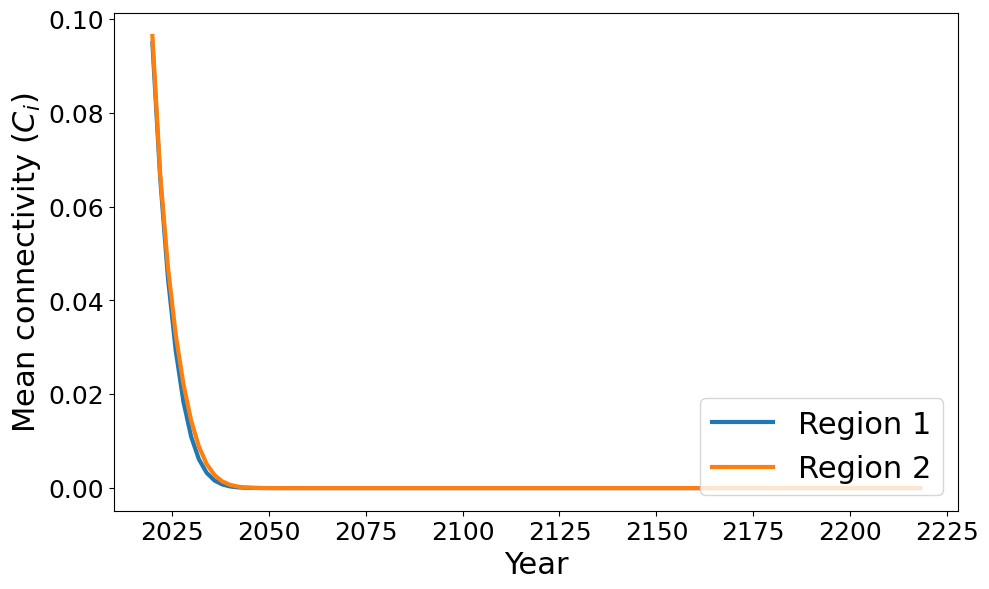

In [ ]:

plt.figure(figsize=(10, 6))

for region in [1, 2]:

    df = summary_d2_gs_r1_only_deter[
        summary_d2_gs_r1_only_deter["region"] == region
    ]

    plt.plot(
        2018 + df["step"] * 2,
        df["mean_C"],
        linewidth=3,
        label=f"Region {region}"
    )

plt.xlabel("Year", fontsize=22)
plt.ylabel(r"Mean colonisation probability ($C_i$)", fontsize=22)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.legend(
    fontsize=22,
    loc="lower right"
)

plt.tight_layout()
plt.show()

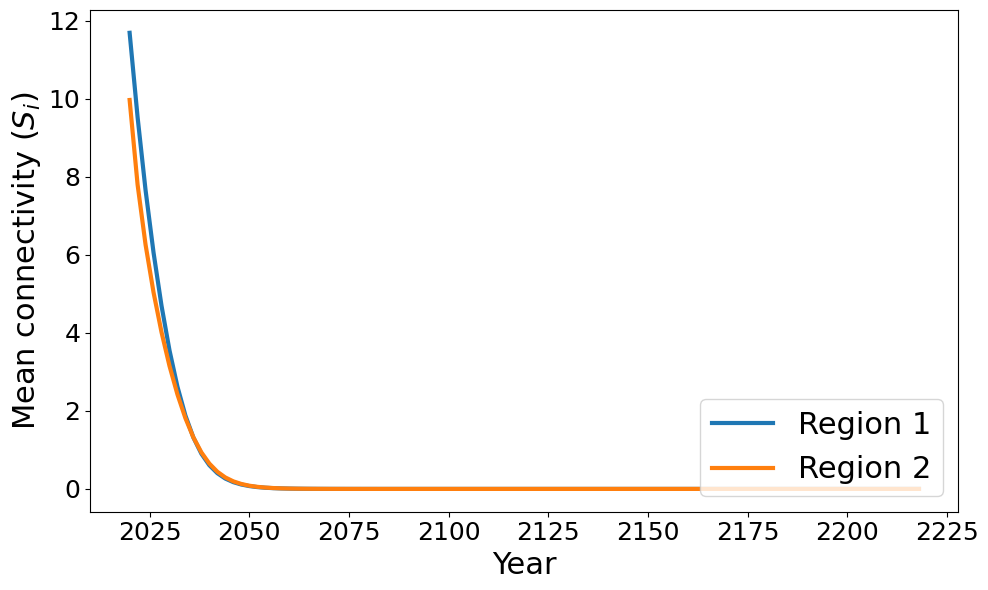

In [ ]:

plt.figure(figsize=(10, 6))

for region in [1, 2]:

    df = summary_d2_gs_r1_only_deter[
        summary_d2_gs_r1_only_deter["region"] == region
    ]

    plt.plot(
        2018 + df["step"] * 2,
        df["mean_S"],
        linewidth=3,
        label=f"Region {region}"
    )

plt.xlabel("Year", fontsize=22)
plt.ylabel(r"Mean connectivity ($S_i$)", fontsize=22)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.legend(
    fontsize=22,
    loc="lower right"
)

plt.tight_layout()
plt.show()

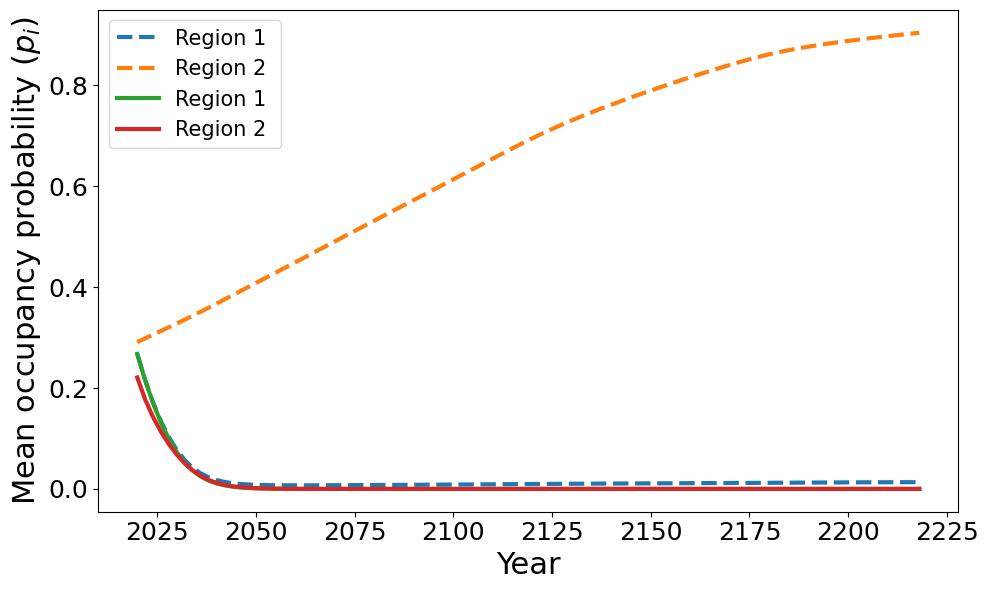

In [ ]:
plt.figure(figsize=(10, 6))

##original
for region in [1, 2]:
    df = summary_d2_gs_deter[
        summary_d2_gs_deter["region"] == region
    ]

    plt.plot(
        2018 + df["step"] * 2,
        df["mean_occupancy"],
        linewidth=3,
        linestyle="--",
        label=f"Region {region}"
    )


###
for region in [1, 2]:
    df = summary_d2_gs_r1_only_deter[
        summary_d2_gs_r1_only_deter["region"] == region
    ]

    plt.plot(
        2018 + df["step"] * 2,
        df["mean_occupancy"],
        linewidth=3,
        linestyle="-",
        label=f"Region {region} "
    )




plt.xlabel("Year", fontsize=22)
plt.ylabel(r"Mean occupancy probability ($p_i$)", fontsize=22)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.legend(
    fontsize=15,
    loc="best"
)

plt.tight_layout()
plt.show()

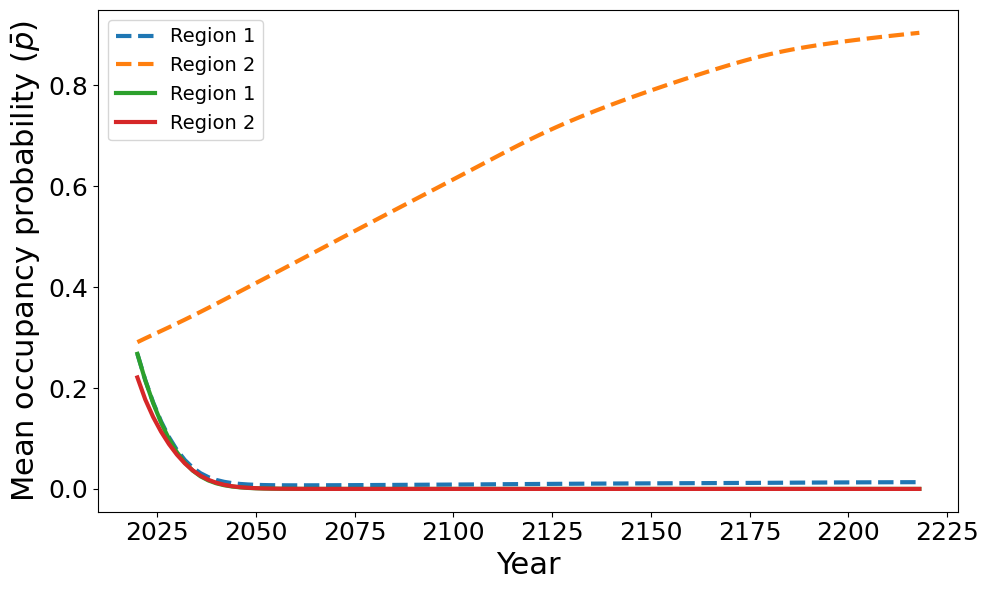

In [ ]:
plt.figure(figsize=(10, 6))

for region in [1, 2]:
    df = summary_d2_gs_deter[
        summary_d2_gs_deter["region"] == region
    ]

    plt.plot(
        2018 + df["step"] * 2,
        df["mean_occupancy"],
        linewidth=3,
        linestyle="--",
        label=f"Region {region}"
    )

for region in [1, 2]:
    df = summary_d2_gs_r1_only_deter[
        summary_d2_gs_r1_only_deter["region"] == region
    ]

    plt.plot(
        2018 + df["step"] * 2,
        df["mean_occupancy"],
        linewidth=3,
        linestyle="-",
        label=f"Region {region}"
    )

plt.xlabel("Year", fontsize=22)
plt.ylabel(r"Mean occupancy probability ($\bar{p}$)", fontsize=22)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.legend(fontsize=14, loc="best")

plt.tight_layout()
plt.show()


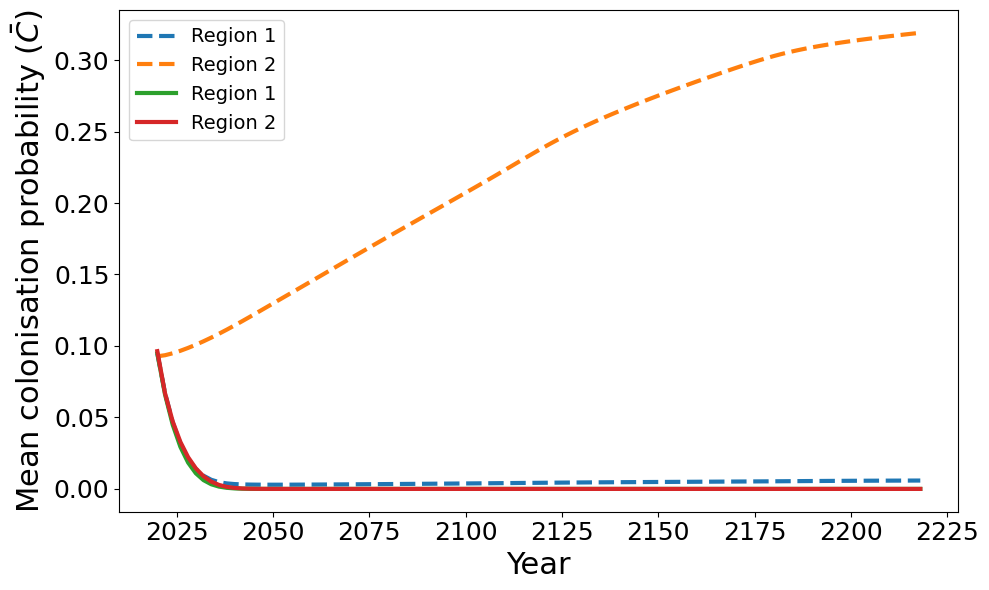

In [ ]:
plt.figure(figsize=(10, 6))

for region in [1, 2]:
    df = summary_d2_gs_deter[
        summary_d2_gs_deter["region"] == region
    ]

    plt.plot(
        2018 + df["step"] * 2,
        df["mean_C"],
        linewidth=3,
        linestyle="--",
        label=f"Region {region}"
    )

for region in [1, 2]:
    df = summary_d2_gs_r1_only_deter[
        summary_d2_gs_r1_only_deter["region"] == region
    ]

    plt.plot(
        2018 + df["step"] * 2,
        df["mean_C"],
        linewidth=3,
        linestyle="-",
        label=f"Region {region}"
    )

plt.xlabel("Year", fontsize=22)
plt.ylabel(r"Mean colonisation probability ($\bar{C}$)", fontsize=22)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.legend(fontsize=14, loc="best")

plt.tight_layout()
plt.show()

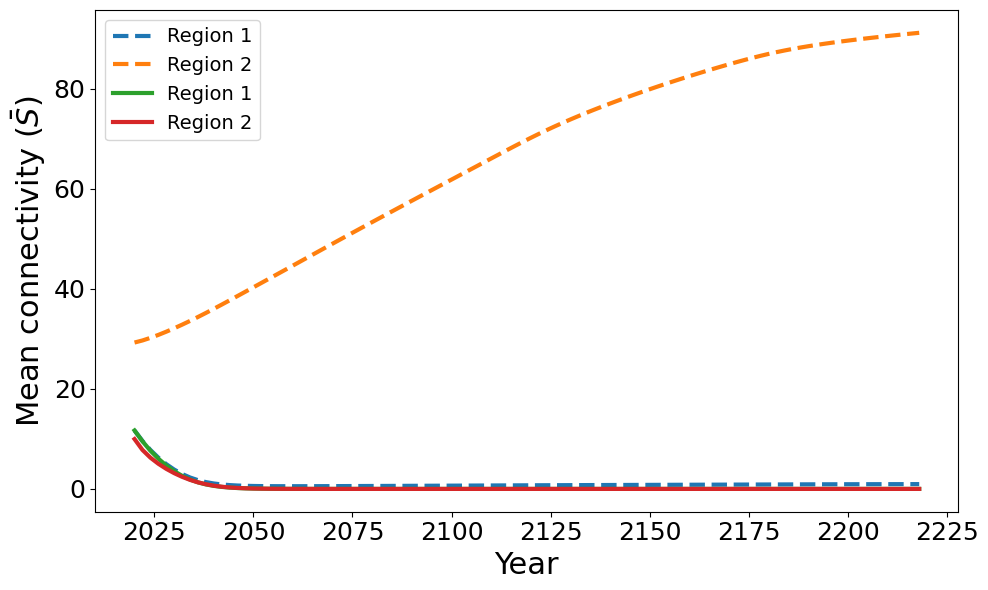

In [ ]:
plt.figure(figsize=(10, 6))

for region in [1, 2]:
    df = summary_d2_gs_deter[
        summary_d2_gs_deter["region"] == region
    ]

    plt.plot(
        2018 + df["step"] * 2,
        df["mean_S"],
        linewidth=3,
        linestyle="--",
        label=f"Region {region}"
    )

for region in [1, 2]:
    df = summary_d2_gs_r1_only_deter[
        summary_d2_gs_r1_only_deter["region"] == region
    ]

    plt.plot(
        2018 + df["step"] * 2,
        df["mean_S"],
        linewidth=3,
        linestyle="-",
        label=f"Region {region}"
    )

plt.xlabel("Year", fontsize=22)
plt.ylabel(r"Mean connectivity ($\bar{S}$)", fontsize=22)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.legend(fontsize=14, loc="best")

plt.tight_layout()
plt.show()


In [ ]:
summary_d2_gs_deter.groupby("region")["mean_E"].first()

,mean_E
region,
1,0.360500
2,0.007686


In [ ]:
summary_d2_gs_r1_only_deter.groupby("region")["mean_E"].first()

,mean_E
region,
1,0.360500
2,0.359211


In [ ]:
print("Original D2:")
print(
    summary_d2_gs_deter
    .groupby("region")["mean_E"]
    .first()
)

print("\nRegion 1 parameters globally:")
print(
    summary_d2_gs_r1_only_deter
    .groupby("region")["mean_E"]
    .first()
)

Original D2:
region
1    0.360500
2    0.007686
Name: mean_E, dtype: float64

Region 1 parameters globally:
region
1    0.360500
2    0.359211
Name: mean_E, dtype: float64


In [ ]:
print(summary_d2_gs_deter.groupby("region")["mean_occupancy"].first())

print(summary_d2_gs_r1_only_deter.groupby("region")["mean_occupancy"].first())

region
1    0.267724
2    0.290921
Name: mean_occupancy, dtype: float64
region
1    0.267724
2    0.220953
Name: mean_occupancy, dtype: float64
